# 04. Feature Selection · 인코딩 · 스케일링 (STEP 6 ~ STEP 7)

`03_split_and_eda.ipynb`에서 train/test 분할(STEP 5)과 EDA를 마쳤습니다.
이 노트북은 그 결과를 근거로 **모델에 투입할 변수를 확정하고, 학습 가능한 행렬로 변환**합니다.

---

## 노트북을 분리한 이유

STEP 6·7은 03의 EDA와 성격이 다릅니다.
EDA는 **관찰**이고, STEP 6·7은 **변환**입니다.

관찰은 몇 번을 다시 해도 데이터가 바뀌지 않지만,
변환은 실행할 때마다 산출물이 갱신되며 이후 모든 단계가 그 산출물에 의존합니다.
두 성격을 한 노트북에 두면 "어디까지가 관찰이고 어디부터가 확정인지" 경계가 흐려집니다.

`02_preprocessing.ipynb`(STEP 0~4) → `03_split_and_eda.ipynb`(STEP 5 + EDA) →
**`04`(STEP 6~7)** 순서로, 각 노트북이 하나의 산출물 집합을 책임집니다.

## 이 노트북 전체를 관통하는 두 가지 원칙

| 원칙 | 내용 |
|---|---|
| **원칙 1. 기준 선언 우선** | 판정 기준을 결과보다 먼저 고정합니다. 결과를 본 뒤 기준을 조정하면 그것은 선택이 아니라 사후 정당화입니다. |
| **원칙 2. fit은 train에만** | 평균·표준편차·범주 목록·그룹 통계 등 데이터에서 학습되는 모든 값은 train에서만 계산하고 test에는 적용만 합니다. |

원칙 2는 스케일러에만 해당하는 것이 아닙니다.
**"데이터를 보고 정한 값"은 전부 해당됩니다.** STEP 6에서 이 점을 먼저 다룹니다.

## 구성

| 구간 | 내용 | 산출물 |
|---|---|---|
| **STEP 6** | 파생변수 신규 생성 · 규칙 기반 변수 선택 · 선택 손실 검증 | `feature_selection_log.csv` |
| **STEP 7** | 범주형 인코딩 · 왜도 변환 · 스케일링 | `X_train.csv` 외 |
| 정리 | 진행 단계 체크 및 다음 단계 |  |

In [1]:
# ── 라이브러리 및 전역 설정 ────────────────────────────────

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'NanumBarunGothic', 'Noto Sans CJK KR', 'Noto Sans CJK JP']:
    if _f in _avail:
        plt.rc('font', family=_f)
        plt.rcParams['axes.unicode_minus'] = False
        print(f'그래프 한글 폰트: {_f}')
        break
else:
    print('한글 폰트 미발견 — 그래프 제목의 한글이 깨질 수 있습니다.')

# 03 노트북과 동일한 시드를 사용해야 교차검증 분할이 재현됩니다.
SEED = 42
TARGET = 'Vocabulary'

train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

y_train = train_df[TARGET]
y_test = test_df[TARGET]

print(f'train: {train_df.shape[0]}행 × {train_df.shape[1]}열')
print(f'test : {test_df.shape[0]}행 × {test_df.shape[1]}열')

# 이 노트북의 모든 성능 비교는 train 내부 5-fold 교차검증으로 수행합니다.
# test는 최종 모델 평가(STEP 4) 전까지 열지 않습니다.
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)

# 변수 선택 과정을 근거와 함께 누적 기록합니다.
# 02 노트북의 preprocessing_log와 같은 역할입니다.
SEL_LOG = []


def log(rule, action, cols, reason):
    # 조치 하나를 로그에 기록합니다. cols는 문자열 또는 리스트를 받습니다.
    if isinstance(cols, str):
        cols = [cols]
    for c in cols:
        SEL_LOG.append({'규칙': rule, '조치': action, '변수': c, '근거': reason})

그래프 한글 폰트: Malgun Gothic
train: 2997행 × 41열
test : 750행 × 41열


In [2]:
# ── 공통 함수 정의 ─────────────────────────────────────────
#
# 이 노트북에서 반복 사용할 두 가지 계산을 함수로 만들어 둡니다.
# 같은 계산을 여러 번 손으로 다시 쓰면 조건이 조금씩 달라져
# 비교 결과를 신뢰할 수 없게 됩니다.


def vif_series(df, cols):
    # 03 노트북 [5-2]와 동일한 정의입니다.
    #   변수 i를 나머지 변수 전체로 회귀 → R²_i → VIF_i = 1 / (1 - R²_i)
    X = df[cols].values.astype(float)
    out = {}
    for i, c in enumerate(cols):
        yi = X[:, i]
        Xi = np.c_[np.ones(len(X)), np.delete(X, i, axis=1)]
        beta, *_ = np.linalg.lstsq(Xi, yi, rcond=None)
        ss_res = ((yi - Xi @ beta) ** 2).sum()
        ss_tot = ((yi - yi.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        out[c] = np.inf if r2 >= 1 - 1e-10 else 1 / (1 - r2)
    return pd.Series(out).sort_values(ascending=False)


def cv_r2(X, y=None, alpha=1.0):
    # train 내부 5-fold 교차검증 R²의 평균과 표준편차를 반환합니다.
    #
    # 왜 단순 LinearRegression이 아니라 Ridge인가:
    #   변수 선택 중간 단계에는 다중공선성이 남아 있어 최소제곱 해가 불안정합니다.
    #   약한 정규화(alpha=1)를 걸면 그 불안정성이 비교 결과를 흔들지 않습니다.
    #
    # 왜 스케일링을 파이프라인 안에 넣는가:
    #   fold마다 train 부분으로만 fit해야 검증 폴드 정보가 새지 않습니다.
    #   밖에서 미리 스케일링하면 그 자체가 누수입니다.
    from sklearn.pipeline import make_pipeline
    y = y_train if y is None else y
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    s = cross_val_score(pipe, X, y, cv=CV, scoring='r2')
    return s.mean(), s.std()


# 03 노트북에서 계산한 EDA 리포트를 판단 근거로 다시 불러옵니다.
eda_report = pd.read_csv('data/eda_feature_report.csv', index_col=0)
print(f'EDA 리포트: {eda_report.shape[0]}개 변수 × {eda_report.shape[1]}개 지표')
print(f'컬럼: {list(eda_report.columns)}')

EDA 리포트: 37개 변수 × 8개 지표
컬럼: ['변수군', 'r(Target)', 'ρ(Target)', '차이', 'r(Token)', '왜도', 'std', 'VIF']


---

# STEP 6. Feature Selection

## 목적
41개 컬럼 중 **모델에 투입할 변수를 확정**하고, 그 근거를 검증 가능한 형태로 남깁니다.

## 변수를 줄여야 하는 이유

변수를 많이 넣을수록 R²는 대체로 올라갑니다. 그런데도 줄이는 이유는 세 가지입니다.

1. **계수 해석 불가** — 03 EDA 5에서 확인한 대로 완전 종속 변수가 5개, VIF 10 이상이 11개입니다.
   겹치는 변수들 사이에서 계수가 임의로 배분되어 부호조차 신뢰할 수 없습니다.
   이 프로젝트의 질문은 "어떤 언어 특성이 어휘 점수를 설명하는가"이므로 이것은 치명적입니다.
2. **과적합** — train 2,997행에 변수가 수십 개면 노이즈를 학습할 여지가 커집니다.
3. **대시보드 실현 가능성** — STEP 6에서 남긴 변수는 전부 예측 시스템에서 실시간으로 계산해야 합니다.
   변수 하나가 곧 구현 부담입니다.

## 판정 기준 — 결과를 보기 전에 고정합니다

**규칙을 먼저 선언하고 기계적으로 적용합니다.**
결과를 본 뒤 기준을 조정하면 "데이터에 맞춰 기준을 골랐다"는 반박을 피할 수 없습니다.

| 규칙 | 대상 | 기준 | 근거 |
|---|---|---|---|
| **R0** | 누수 위험 | 분할 전에 **전체 데이터의 그룹 통계**로 계산된 변수 | train 기준으로 재계산 |
| **R1** | 비피처·원본 | 텍스트 원문, 파생변수로 대체된 원본 컬럼 | 모델 입력이 아니거나 중복 |
| **R2** | 완전 종속 | 다른 변수들의 합이 정확히 1 (VIF = ∞) | 설계행렬이 특이해져 해가 유일하지 않음 |
| **R3** | 고상관 쌍 | 변수 간 \|r\| > 0.85 → `r(Target)` 열세인 쪽 제거 | 03 EDA 5와 동일 임계값 |
| **R4** | 무예측 | \|r(Target)\| < 0.10 | 03에서 사용한 판정 구간의 하한 |
| **R5** | 다중공선성 | VIF ≥ 10 → 최댓값 1개 제거 후 재계산, 반복 | 03 EDA 5에서 선언한 임계값 |

**예외 조항도 미리 선언합니다.**
`flag_very_short`는 R4에서 면제합니다. 이 변수의 목적은 예측이 아니라
`MTLD_valid`의 대치 여부 표시이며, 제거하면 어느 행이 대치되었는지 정보가 함께 사라집니다.
(02 노트북 파생변수 정의서 G군 참조)

## 신규 생성

02 노트북의 검증 결과에서 도출된 조치 1건을 여기서 실행합니다.

| 변수 | 계산식 | 근거 |
|---|---|---|
| `clean_beyond_2k` | `beyond_2k_ratio − oov_ratio` | 상쇄된 두 신호를 분리 (r 0.055 → 0.258, 전체 데이터 기준) |

In [3]:
# ── [6-1] 신규 파생변수 생성: clean_beyond_2k ─────────────
#
# 02 노트북에서 확인한 문제:
#   beyond_2k_ratio(빈도 2,000위 밖 토큰 비율)는 성격이 정반대인 두 종류를 함께 셉니다.
#     ├─ 고급 어휘   substantial, considerable  → 점수를 올림 (+)
#     └─ 철자 오류   enviroment, alot, becuase  → 점수를 내림 (−)
#   두 신호가 한 변수 안에서 상쇄되어 r ≈ 0이 되었습니다.
#
# 조치: 오류 성분(oov_ratio)을 빼서 고급 어휘 성분만 남깁니다.
#
# 이 계산은 행 단위 뺄셈이므로 다른 행의 정보를 쓰지 않습니다.
# 따라서 train과 test에 각각 독립적으로 적용해도 누수가 발생하지 않습니다.
# (평균·표준편차를 쓰는 계산이었다면 train에서만 fit해야 했습니다.)

for _df in (train_df, test_df):
    _df['clean_beyond_2k'] = _df['beyond_2k_ratio'] - _df['oov_ratio']

# 02의 결론이 train에서도 재현되는지 확인합니다.
# 02는 분할 전 전체 데이터 기준이었으므로 낙관적으로 편향된 값이었습니다.
_before_r = train_df['beyond_2k_ratio'].corr(y_train)
_after_r = train_df['clean_beyond_2k'].corr(y_train)
_before_tok = train_df['beyond_2k_ratio'].corr(train_df['Token'])
_after_tok = train_df['clean_beyond_2k'].corr(train_df['Token'])

print('오류 성분 제거 효과 (train 기준 재검증)')
print(f'{"":22s} {"r(Target)":>10s} {"r(Token)":>10s}')
print(f'{"beyond_2k_ratio":22s} {_before_r:>10.4f} {_before_tok:>10.4f}')
print(f'{"clean_beyond_2k":22s} {_after_r:>10.4f} {_after_tok:>10.4f}')
print(f'\n예측력 {abs(_after_r) / abs(_before_r):.1f}배 상승')
print(f'길이 교란 |r(Token)| = {abs(_after_tok):.3f} — 사실상 길이와 독립')

log('신규', '생성', 'clean_beyond_2k',
    f'beyond_2k_ratio - oov_ratio. 오류 성분 분리로 r {_before_r:.3f} → {_after_r:.3f}')

오류 성분 제거 효과 (train 기준 재검증)
                        r(Target)   r(Token)
beyond_2k_ratio            0.0494    -0.0911
clean_beyond_2k            0.2519    -0.0351

예측력 5.1배 상승
길이 교란 |r(Token)| = 0.035 — 사실상 길이와 독립


In [4]:
# ── [6-2] 파생의 파생 검토: clean_soph_z (기각 후보) ──────
#
# 02 노트북은 "clean_beyond_2k를 재료로 soph_z를 다시 계산해볼 가치가 있다"고
# 제안했습니다. 실행하지 않고 판단할 수는 없으므로 계산해서 확인합니다.
#
# 주의: 이 계산은 프롬프트 그룹의 평균·표준편차를 사용합니다.
#       그룹 통계는 train에서만 계산하고 test에는 적용만 해야 합니다.

_g = train_df.groupby('prompt')['clean_beyond_2k'].agg(['mean', 'std'])
_gm, _gs = train_df['clean_beyond_2k'].mean(), train_df['clean_beyond_2k'].std()

# train에 없던 프롬프트가 test에 나타나면 전체 통계로 대체합니다.
_m = train_df['prompt'].map(_g['mean']).fillna(_gm)
_s = train_df['prompt'].map(_g['std']).fillna(_gs).replace(0, _gs)
_clean_soph_z = (train_df['clean_beyond_2k'] - _m) / _s

_r_new = _clean_soph_z.corr(y_train)
_dup = _clean_soph_z.corr(train_df['clean_beyond_2k'])

print('clean_soph_z (프롬프트 내 표준화) 검토')
print(f'  r(Target)              : {_r_new:+.4f}')
print(f'  원재료와의 상관        : {_dup:+.4f}')
print(f'  clean_beyond_2k r(Target): {_after_r:+.4f}')
print()

if abs(_r_new) <= abs(_after_r) or _dup > 0.85:
    print('판정: 기각')
    print('  표준화 후 예측력이 개선되지 않았고, 원재료와 r > 0.85로 사실상 같은 변수입니다.')
    print('  프롬프트별 어휘 수준 차이가 애초에 작다는 뜻이며,')
    print('  02에서 len_z_in_prompt에 대해 내린 결론(F군 상대화 실패)과 일치합니다.')
    log('신규', '기각', 'clean_soph_z',
        f'표준화 이득 없음 (r {_r_new:.3f} ≤ {_after_r:.3f}), 원재료와 r={_dup:.3f}')
else:
    print('판정: 채택 검토')

clean_soph_z (프롬프트 내 표준화) 검토
  r(Target)              : +0.2454
  원재료와의 상관        : +0.8988
  clean_beyond_2k r(Target): +0.2519

판정: 기각
  표준화 후 예측력이 개선되지 않았고, 원재료와 r > 0.85로 사실상 같은 변수입니다.
  프롬프트별 어휘 수준 차이가 애초에 작다는 뜻이며,
  02에서 len_z_in_prompt에 대해 내린 결론(F군 상대화 실패)과 일치합니다.


---

## [6-3] R0 — 분할 전에 계산된 그룹 통계 재점검

### 문제

`02_preprocessing.ipynb` STEP 4는 **분할 이전**에 실행됐습니다.
그런데 F군(과제 상대화) 변수들은 계산에 **프롬프트 그룹의 통계**를 씁니다.

```
len_z_in_prompt = (Token − 그 프롬프트의 평균 Token) / 그 프롬프트의 표준편차
                              └─────────ㅡ 여기에 test 행이 포함되어 있음
```

즉 train 행의 변수값이 test 행의 정보를 이미 반영한 상태입니다.
`prompt_grouped`(30편 미만 → OTHER)도 마찬가지로 전체 편수를 세어 만들었습니다.

### 얼마나 심각한가

이것은 **타겟 누수가 아니라 특징 누수(feature leakage)** 입니다.
점수(`Vocabulary`)는 사용하지 않고 길이의 그룹 평균만 썼으므로 영향은 제한적입니다.

그러나 "test는 존재하지 않는 것처럼 다룬다"는 원칙에는 어긋납니다.
실제 운영 환경에서는 미래에 들어올 에세이의 평균을 미리 알 수 없기 때문에,
이 상태로 측정한 성능은 재현되지 않을 수 있습니다.

### 조치

**제거가 아니라 재계산**을 택합니다.
변수 자체는 유효하고, 그룹 통계를 train으로만 다시 계산하면 문제가 사라지기 때문입니다.
제거하면 멀쩡한 변수를 절차 문제로 잃게 됩니다.

In [5]:
# ── [6-3] len_z_in_prompt 재계산 (train 기준) ─────────────
#
# 재계산 절차:
#   ① train에서만 프롬프트별 Token의 평균·표준편차를 구한다
#   ② train과 test 모두 그 통계로 표준화한다
#   ③ train에 없던 프롬프트는 train 전체 통계로 대체한다
#
# ③이 필요한 이유: test에만 존재하는 프롬프트가 있으면 매핑이 결측이 됩니다.
# 실제 운영에서도 처음 보는 주제가 들어올 수 있으므로 반드시 필요한 처리입니다.

_stat = train_df.groupby('prompt')['Token'].agg(['mean', 'std'])
TOKEN_GM, TOKEN_GS = train_df['Token'].mean(), train_df['Token'].std()


def recompute_len_z(df):
    m = df['prompt'].map(_stat['mean']).fillna(TOKEN_GM)
    s = df['prompt'].map(_stat['std']).fillna(TOKEN_GS).replace(0, TOKEN_GS)
    return (df['Token'] - m) / s


_old_train = train_df['len_z_in_prompt'].copy()
train_df['len_z_in_prompt'] = recompute_len_z(train_df)
test_df['len_z_in_prompt'] = recompute_len_z(test_df)

_agree = _old_train.corr(train_df['len_z_in_prompt'])
_unseen = len(set(test_df['prompt']) - set(train_df['prompt']))

print('len_z_in_prompt 재계산 결과 (train 기준)')
print(f'  기존값과의 상관     : {_agree:.5f}')
print(f'  최대 변화량         : {(_old_train - train_df["len_z_in_prompt"]).abs().max():.4f}')
print(f'  r(Target) 기존 → 신 : {_old_train.corr(y_train):+.4f} → '
      f'{train_df["len_z_in_prompt"].corr(y_train):+.4f}')
print(f'  train에 없는 test 프롬프트: {_unseen}종')
print()
print('해석: 값 자체는 거의 변하지 않았습니다(r = 0.997).')
print('80%의 표본으로 계산한 그룹 평균이 100%로 계산한 것과 크게 다르지 않기 때문입니다.')
print('중요한 것은 값의 변화량이 아니라 **절차의 정당성**입니다.')
print('영향이 작다는 것은 사후에 확인된 사실이지, 생략의 근거가 될 수 없습니다.')

log('R0', '재계산', 'len_z_in_prompt',
    f'분할 전 전체 데이터 그룹통계로 계산되어 있었음 → train 기준 재계산 (기존값과 r={_agree:.4f})')

len_z_in_prompt 재계산 결과 (train 기준)
  기존값과의 상관     : 0.99650
  최대 변화량         : 0.6514
  r(Target) 기존 → 신 : +0.2701 → +0.2708
  train에 없는 test 프롬프트: 0종

해석: 값 자체는 거의 변하지 않았습니다(r = 0.997).
80%의 표본으로 계산한 그룹 평균이 100%로 계산한 것과 크게 다르지 않기 때문입니다.
중요한 것은 값의 변화량이 아니라 **절차의 정당성**입니다.
영향이 작다는 것은 사후에 확인된 사실이지, 생략의 근거가 될 수 없습니다.


In [6]:
# ── [6-4] R1: 비피처 및 원본 컬럼 제거 ────────────────────
#
# 두 종류를 제거합니다.
#
# (가) 모델 입력이 될 수 없는 컬럼
#      full_text : 문자열 원문. 이 프로젝트는 정형 피처 기반 회귀이므로 입력이 아닙니다.
#      prompt / prompt_grouped : 범주형. STEP 7에서 인코딩해 별도로 합류시킵니다.
#      Vocabulary : 타겟. 피처에 넣으면 완전한 누수입니다.
#
# (나) 파생변수로 대체된 원본 컬럼 (02 정의서 H군)
#      원본은 전부 "규모"를 재는 변수이고, 03 EDA 4에서 r(Token) 0.62~1.00으로
#      사실상 길이를 측정하고 있음이 확인됐습니다.
#      길이 자체를 통제 변수로 쓸지는 [6-9]에서 별도로 판단하고,
#      여기서는 일단 후보군에서 전부 내립니다.

NON_FEATURE = ['full_text', 'prompt', 'prompt_grouped', TARGET]
ORIGINAL_H = ['num_words', 'num_words3', 'num_sent', 'num_para', 'num_word_div_para',
              'MTLD', 'TTR', 'Type', 'Token']

# 원본과 파생의 대응 관계를 명시합니다. 근거 없이 지운 것이 아님을 남기는 것이 목적입니다.
REPLACED_BY = {
    'TTR': 'ttr_ratio (TTR/100, 값이 동일)',
    'MTLD': 'MTLD_valid (100토큰 미만 무효 처리 반영)',
    'Type': 'guiraud = Type/√Token (길이 보정형)',
    'Token': '길이 대표 변수로 [6-9]에서 재검토',
    'num_words': 'Token (r = 0.80)',
    'num_words3': 'Token (r = 0.999)',
    'num_sent': 'mean_sent_length 등 E군 구문 변수',
    'num_para': 'sent_per_para 등 E군 구문 변수',
    'num_word_div_para': 'mean_para_length (r = 0.9997)',
}

pool = [c for c in train_df.columns if c not in NON_FEATURE]
print(f'전체 컬럼에서 비피처 제외 → 후보 {len(pool)}개')

print('\n원본 컬럼 제거 및 대체 관계')
for c in ORIGINAL_H:
    print(f'  {c:20s} → {REPLACED_BY[c]}')
    log('R1', '제거', c, f'파생변수로 대체: {REPLACED_BY[c]}')

log('R1', '제외', NON_FEATURE, '모델 입력 대상 아님 (원문·범주형·타겟)')

pool_r1 = [c for c in pool if c not in ORIGINAL_H]
print(f'\nR1 적용 후 후보: {len(pool_r1)}개')

전체 컬럼에서 비피처 제외 → 후보 38개

원본 컬럼 제거 및 대체 관계
  num_words            → Token (r = 0.80)
  num_words3           → Token (r = 0.999)
  num_sent             → mean_sent_length 등 E군 구문 변수
  num_para             → sent_per_para 등 E군 구문 변수
  num_word_div_para    → mean_para_length (r = 0.9997)
  MTLD                 → MTLD_valid (100토큰 미만 무효 처리 반영)
  TTR                  → ttr_ratio (TTR/100, 값이 동일)
  Type                 → guiraud = Type/√Token (길이 보정형)
  Token                → 길이 대표 변수로 [6-9]에서 재검토

R1 적용 후 후보: 29개


In [7]:
# ── [6-5] R2: 완전 종속 해소 ──────────────────────────────
#
# 03 EDA 5에서 VIF = ∞로 판정된 5개 변수의 원인을 먼저 특정합니다.
# "VIF가 크니까 지운다"가 아니라 "왜 무한대인지"를 밝혀야
# 어느 쪽을 남길지 결정할 수 있습니다.

_band = train_df['k1_ratio'] + train_df['k2_ratio'] + train_df['beyond_2k_ratio']
_dens = train_df['lexical_density'] + train_df['function_word_ratio']

print('완전 종속의 원인 — 정의상 합이 1인 변수 집합')
print(f'  k1_ratio + k2_ratio + beyond_2k_ratio : '
      f'min={_band.min():.10f}, max={_band.max():.10f}')
print(f'  lexical_density + function_word_ratio : '
      f'min={_dens.min():.10f}, max={_dens.max():.10f}')
print()
print('두 집합 모두 합이 정확히 1입니다.')
print('빈도 밴드는 모든 토큰을 3구간으로 남김없이 분할하고,')
print('내용어와 기능어도 전체 토큰을 둘로 남김없이 나눕니다.')
print('따라서 한 변수는 나머지로 완벽히 재현되며, 설계행렬이 특이(singular)해집니다.')
print()

# 조치 1) 빈도 밴드 — clean_beyond_2k로 대체
#   k2_ratio는 유일하게 단변량 신호가 있어(r = 0.13) 남깁니다.
#   k1_ratio, beyond_2k_ratio는 clean_beyond_2k에 정보가 승계되었습니다.
# 조치 2) 내용어/기능어 — 03 EDA에서 C군 전체가 |r| < 0.10으로 실패했습니다.
#   여집합 관계라 어차피 한쪽만 남겨야 하는데, 남길 이유가 없으므로 둘 다 R4로 넘깁니다.
#   여기서는 완전 종속만 해소하기 위해 function_word_ratio 한쪽을 먼저 내립니다.

drop_r2 = ['k1_ratio', 'beyond_2k_ratio', 'function_word_ratio']
for c in drop_r2:
    r = eda_report.loc[c, 'r(Target)'] if c in eda_report.index else np.nan
    print(f'  제거: {c:22s} (r(Target) = {r:+.3f})')

log('R2', '제거', ['k1_ratio', 'beyond_2k_ratio'],
    'k1+k2+beyond_2k = 1 (완전 종속). 정보는 clean_beyond_2k와 k2_ratio가 승계')
log('R2', '제거', 'function_word_ratio',
    'lexical_density와 합이 1인 여집합. 부호만 반대인 동일 변수')

pool_r2 = [c for c in pool_r1 if c not in drop_r2]
print(f'\nR2 적용 후 후보: {len(pool_r2)}개')
_v = vif_series(train_df, pool_r2)
print(f'VIF 무한대 잔존: {(_v == np.inf).sum()}개  (최대 VIF: {_v.max():.2f})')

완전 종속의 원인 — 정의상 합이 1인 변수 집합
  k1_ratio + k2_ratio + beyond_2k_ratio : min=1.0000000000, max=1.0000000000
  lexical_density + function_word_ratio : min=1.0000000000, max=1.0000000000

두 집합 모두 합이 정확히 1입니다.
빈도 밴드는 모든 토큰을 3구간으로 남김없이 분할하고,
내용어와 기능어도 전체 토큰을 둘로 남김없이 나눕니다.
따라서 한 변수는 나머지로 완벽히 재현되며, 설계행렬이 특이(singular)해집니다.

  제거: k1_ratio               (r(Target) = -0.108)
  제거: beyond_2k_ratio        (r(Target) = +0.049)
  제거: function_word_ratio    (r(Target) = -0.095)

R2 적용 후 후보: 26개


VIF 무한대 잔존: 0개  (최대 VIF: 90.56)


In [8]:
# ── [6-6] R3: 고상관 쌍 정리 ──────────────────────────────
#
# 기준: 변수 간 |r| > 0.85인 쌍에서 r(Target) 절댓값이 작은 쪽을 제거합니다.
#
# 처리 순서가 중요합니다. 상관이 높은 순서로 처리하되,
# 이미 제거된 변수가 포함된 쌍은 건너뜁니다.
# 그렇게 하지 않으면 A-B, B-C 쌍에서 B를 두 번 지우거나
# 연쇄적으로 필요 이상의 변수를 잃게 됩니다.

TH_CORR = 0.85
corr_m = train_df[pool_r2].corr()
r_target = train_df[pool_r2].corrwith(y_train)

# 상삼각만 추출해 각 쌍이 한 번씩만 나오게 합니다.
_pairs = (corr_m.abs()
          .where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
          .stack().sort_values(ascending=False))
_pairs = _pairs[_pairs > TH_CORR]

drop_r3 = []
print(f'상관 {TH_CORR} 초과 쌍 처리')
for (a, b), v in _pairs.items():
    if a in drop_r3 or b in drop_r3:
        print(f'  {a:22s} ↔ {b:22s} r={v:.3f}  → 건너뜀 (한쪽 이미 제거)')
        continue
    loser = b if abs(r_target[a]) >= abs(r_target[b]) else a
    keeper = a if loser == b else b
    drop_r3.append(loser)
    print(f'  {a:22s} ↔ {b:22s} r={v:.3f}  → 유지 {keeper} / 제거 {loser} '
          f'(r(Target) {r_target[keeper]:+.3f} vs {r_target[loser]:+.3f})')
    log('R3', '제거', loser,
        f'{keeper}와 r={v:.3f}로 중복. r(Target) 열세 ({r_target[loser]:+.3f} < {r_target[keeper]:+.3f})')

pool_r3 = [c for c in pool_r2 if c not in drop_r3]
print(f'\nR3 적용 후 후보: {len(pool_r3)}개')

상관 0.85 초과 쌍 처리
  sent_length_std        ↔ sent_length_max        r=0.954  → 유지 sent_length_std / 제거 sent_length_max (r(Target) -0.168 vs -0.139)
  herdan_c               ↔ ttr_ratio              r=0.943  → 유지 herdan_c / 제거 ttr_ratio (r(Target) +0.121 vs -0.010)
  herdan_c               ↔ content_ttr            r=0.909  → 유지 herdan_c / 제거 content_ttr (r(Target) +0.121 vs +0.050)
  ttr_ratio              ↔ content_ttr            r=0.878  → 건너뜀 (한쪽 이미 제거)
  mean_word_length       ↔ long_word_ratio        r=0.864  → 유지 mean_word_length / 제거 long_word_ratio (r(Target) +0.232 vs +0.210)

R3 적용 후 후보: 22개


In [9]:
# ── [6-7] R4: 단변량 예측력 없는 변수 제거 ────────────────
#
# 기준: |r(Target)| < 0.10
#
# 이 규칙의 한계를 먼저 밝힙니다.
# 단변량 상관은 **다른 변수와 조합했을 때의 기여**를 측정하지 못합니다.
# 억제 변수(suppressor variable)처럼 단독 상관은 0이지만 다른 변수의 잡음을
# 상쇄해 모델을 개선하는 경우가 실제로 존재합니다.
#
# 그래서 이 단계에서 제거한 결과가 성능을 떨어뜨리지 않았는지
# [6-10]에서 교차검증으로 반드시 검증합니다. 규칙만 믿고 넘어가지 않습니다.

TH_R = 0.10
KEEP_EXEMPT = {'flag_very_short'}   # 사전 선언한 예외

r_target3 = train_df[pool_r3].corrwith(y_train)
drop_r4 = [c for c in pool_r3 if abs(r_target3[c]) < TH_R and c not in KEEP_EXEMPT]

print(f'|r(Target)| < {TH_R} 변수')
for c in sorted(drop_r4, key=lambda x: abs(r_target3[x])):
    print(f'  제거: {c:22s} r = {r_target3[c]:+.4f}')
    log('R4', '제거', c, f'단변량 예측력 없음 (|r| = {abs(r_target3[c]):.3f} < {TH_R})')

print('\n예외 적용 (제거하지 않음)')
for c in KEEP_EXEMPT & set(pool_r3):
    print(f'  유지: {c:22s} r = {r_target3[c]:+.4f}')
    print(f'         └ MTLD_valid의 대치 여부 표시가 목적. 제거 시 대치 정보 소실')
    log('R4', '예외 유지', c, 'MTLD_valid 대치 표시용. 예측이 아니라 정보 보존이 목적')

pool_r4 = [c for c in pool_r3 if c not in drop_r4]
print(f'\nR4 적용 후 후보: {len(pool_r4)}개')

|r(Target)| < 0.1 변수
  제거: n_pii                  r = +0.0298
  제거: repeat_bigram_ratio    r = -0.0377
  제거: prompt_freq            r = -0.0449
  제거: soph_z_in_prompt       r = +0.0468
  제거: flag_len_outlier       r = +0.0582
  제거: mean_para_length       r = +0.0709
  제거: lexical_density        r = +0.0954

예외 적용 (제거하지 않음)
  유지: flag_very_short        r = -0.0455
         └ MTLD_valid의 대치 여부 표시가 목적. 제거 시 대치 정보 소실

R4 적용 후 후보: 15개


In [10]:
# ── [6-8] R5: VIF 반복 제거 ───────────────────────────────
#
# 기준: VIF ≥ 10인 변수가 있으면 **가장 큰 것 하나만** 제거하고 전체를 재계산합니다.
#
# 한 번에 전부 지우면 안 되는 이유:
#   VIF는 "나머지 전체"를 기준으로 계산됩니다.
#   A와 B가 서로 겹쳐 둘 다 VIF 20이라면, A를 지우는 순간 B의 VIF는 정상으로 내려갑니다.
#   동시에 지우면 남겨도 됐을 변수까지 잃습니다.

TH_VIF = 10.0
cur = list(pool_r4)
step = 0

print('VIF 반복 제거')
while True:
    v = vif_series(train_df, cur)
    if v.max() < TH_VIF:
        print(f'  종료 — 최대 VIF {v.max():.2f} < {TH_VIF}')
        break
    step += 1
    worst = v.index[0]
    print(f'  [{step}] 제거: {worst:22s} VIF = {v.iloc[0]:.2f} '
          f'(잔여 {len(cur) - 1}개)')
    log('R5', '제거', worst, f'VIF = {v.iloc[0]:.2f} ≥ {TH_VIF} (다중공선성)')
    cur.remove(worst)

pool_r5 = cur
print(f'\nR5 적용 후 후보: {len(pool_r5)}개')
print('\n최종 VIF')
_vf = vif_series(train_df, pool_r5)
_vt = pd.DataFrame({'VIF': _vf.round(2)})
_vt['r(Target)'] = [round(train_df[c].corr(y_train), 3) for c in _vt.index]
_vt['판정'] = np.where(_vt['VIF'] >= 5, '주의', '양호')
print(_vt.to_string())

VIF 반복 제거
  종료 — 최대 VIF 8.94 < 10.0

R5 적용 후 후보: 15개

최종 VIF
                        VIF  r(Target)  판정
herdan_c               8.94      0.121  주의
guiraud                7.18      0.380  주의
mean_syllables         4.61      0.234  양호
len_z_in_prompt        4.19      0.271  양호
mean_word_length       3.93      0.232  양호
hapax_ratio            3.45      0.110  양호
MTLD_valid             2.66      0.346  양호
sent_length_std        1.75     -0.168  양호
mean_sent_length       1.72     -0.162  양호
clean_beyond_2k        1.54      0.252  양호
academic_suffix_ratio  1.48      0.102  양호
flag_very_short        1.30     -0.046  양호
k2_ratio               1.30      0.132  양호
sent_per_para          1.22      0.176  양호
oov_ratio              1.19     -0.315  양호


---

## [6-9] 길이 변수를 어떻게 다룰 것인가

### 상황

R5까지 적용한 결과 `len_z_in_prompt`가 살아남았습니다.
그런데 이 변수는 03 EDA 4 기준 `r(Token) = 0.947`입니다.
**이름은 "과제 상대화"지만 실제로는 텍스트 길이를 재고 있습니다.**

02 노트북 정의서도 이 변수를 🔄(재해석) 으로 판정했습니다.

### 세 가지 선택지

| 안 | 내용 | 논점 |
|---|---|---|
| **가** | 길이 계열을 전부 제거 | 길이 교란이 완전히 사라지지만, 길이의 정당한 예측력도 함께 버림 |
| **나** | `len_z_in_prompt`를 `Token`으로 교체 | 이름과 의미가 일치해 해석이 명확 |
| **다** | 규칙 결과대로 `len_z_in_prompt` 유지 | 규칙을 사후 수정하지 않음 |

### 판단의 기준: 교란변수는 빼는 것이 아니라 넣는 것

통계적으로 교란변수(confounder)를 다루는 정석은 **모델에서 제외하는 것이 아니라
명시적으로 포함하는 것**입니다.

길이를 빼면 "길이의 영향이 사라진" 모델이 되는 게 아니라,
길이와 상관된 다른 변수들이 길이 효과까지 흡수해 **계수가 부풀려집니다**.
길이를 넣어야 나머지 계수를 "같은 길이의 글끼리 비교했을 때"로 읽을 수 있습니다.

따라서 **가는 기각**합니다. 남는 것은 나와 다이며, 둘 다 길이를 포함하되
어느 형태로 넣을지의 문제입니다. 아래 셀에서 수치로 비교합니다.

In [11]:
# ── [6-9] 길이 변수 형태 비교 ─────────────────────────────
#
# 비교 기준 두 가지:
#   ① train 5-fold 교차검증 R² — 예측력
#   ② 최대 VIF — 계수 해석 가능성 (사전 선언한 임계값 10)
#
# 교차검증 표준편차를 반드시 함께 봅니다.
# 차이가 표준편차보다 작으면 그것은 개선이 아니라 노이즈입니다.

_others = [c for c in pool_r5 if c != 'len_z_in_prompt']

cands = {
    '가. 길이 계열 전부 제외': _others,
    '나. len_z → Token 교체': _others + ['Token'],
    '다. len_z 유지 (규칙 결과)': pool_r5,
    '참고. len_z + Token 동시': pool_r5 + ['Token'],
}

rows = []
for name, cols in cands.items():
    m, s = cv_r2(train_df[cols])
    rows.append({'안': name, '변수 수': len(cols), 'CV R²': round(m, 4),
                 '표준편차': round(s, 4), '최대 VIF': round(vif_series(train_df, cols).max(), 2)})

cmp_len = pd.DataFrame(rows)
cmp_len['VIF 판정'] = np.where(cmp_len['최대 VIF'] >= TH_VIF, '✗ 기준 위반', '✓ 통과')
print(cmp_len.to_string(index=False))

_best = cmp_len.loc[cmp_len['CV R²'].idxmax()]
_sd = cmp_len['표준편차'].mean()
print(f'\n최고-최저 R² 차이: {cmp_len["CV R²"].max() - cmp_len["CV R²"].min():.4f}')
print(f'교차검증 표준편차 평균: {_sd:.4f}')
print('→ 네 안의 성능 차이는 전부 표준편차보다 작습니다. 예측력으로는 구분되지 않습니다.')
print()
print('따라서 VIF 기준으로 결정합니다.')
print('  · 나(Token 교체)와 참고(동시 투입)는 최대 VIF가 10을 넘어 사전 선언 기준을 위반합니다.')
print('  · 다(규칙 결과)를 채택합니다. 기준을 사후에 바꾸지 않았다는 점에서도 일관됩니다.')
print()
print('단, 변수의 의미는 이름이 아니라 실측으로 기술합니다.')
print(f'  len_z_in_prompt: r(Token) = {train_df["len_z_in_prompt"].corr(train_df["Token"]):.3f}')
print('  → "과제 상대화 지표"가 아니라 **길이 통제 변수**로 해석하고 보고합니다.')
print('     (02 노트북이 E군에 적용한 재해석과 동일한 처리입니다.)')

log('R5-보완', '유지', 'len_z_in_prompt',
    'Token 교체안은 VIF 10 초과로 기준 위반. 길이 통제 변수로 재해석해 유지')

                   안  변수 수  CV R²   표준편차  최대 VIF  VIF 판정
      가. 길이 계열 전부 제외    14 0.2969 0.0389    4.60    ✓ 통과
 나. len_z → Token 교체    15 0.2968 0.0390   13.47 ✗ 기준 위반
 다. len_z 유지 (규칙 결과)    15 0.3003 0.0400    8.94    ✓ 통과
참고. len_z + Token 동시    16 0.3031 0.0407   19.99 ✗ 기준 위반

최고-최저 R² 차이: 0.0063
교차검증 표준편차 평균: 0.0397
→ 네 안의 성능 차이는 전부 표준편차보다 작습니다. 예측력으로는 구분되지 않습니다.

따라서 VIF 기준으로 결정합니다.
  · 나(Token 교체)와 참고(동시 투입)는 최대 VIF가 10을 넘어 사전 선언 기준을 위반합니다.
  · 다(규칙 결과)를 채택합니다. 기준을 사후에 바꾸지 않았다는 점에서도 일관됩니다.

단, 변수의 의미는 이름이 아니라 실측으로 기술합니다.
  len_z_in_prompt: r(Token) = 0.951
  → "과제 상대화 지표"가 아니라 **길이 통제 변수**로 해석하고 보고합니다.
     (02 노트북이 E군에 적용한 재해석과 동일한 처리입니다.)


             변수 집합  변수 수  CV R²      ±  변수당 R²
     길이 단독 (Token)     1 0.0664 0.0177  0.0664
    핵심 4개 (02 정의서)     4 0.2634 0.0448  0.0659
선택 15개 (STEP 6 결과)    15 0.3003 0.0400  0.0200
         전체 파생 28개    28 0.3134 0.0471  0.0112

전체 대비 선택으로 잃은 R²: 0.0131
교차검증 표준편차     : ±0.0374
판정: 손실이 노이즈 범위 안 — 선택 타당

변수 수는 28개 → 15개로 46% 줄었고,
그 대가로 잃은 R²는 교차검증 오차보다 작습니다.
한편 완전 종속(VIF ∞) 변수가 사라져 계수 해석이 비로소 가능해졌습니다.


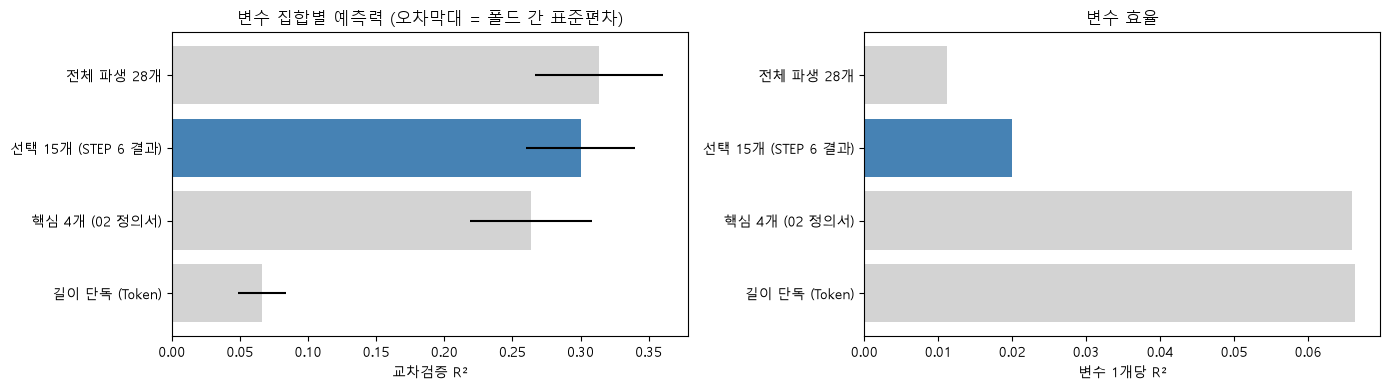

In [12]:
# ── [6-10] 선택으로 정보를 잃었는지 검증 ──────────────────
#
# R1~R5는 규칙일 뿐이고, 규칙이 옳았다는 보장은 없습니다.
# 특히 R4(단변량 상관)는 조합 효과를 못 보므로 실제로 손실이 있었을 수 있습니다.
#
# 검증 방법: 변수 집합별 교차검증 R²를 비교합니다.
# 선택 집합이 전체 집합에 크게 못 미치면 규칙을 재검토해야 합니다.

SELECTED = list(pool_r5)

_all_derived = [c for c in pool_r1 if c not in ('function_word_ratio',)]  # 특이행렬 회피
benchmarks = {
    '길이 단독 (Token)': ['Token'],
    '핵심 4개 (02 정의서)': ['guiraud', 'MTLD_valid', 'oov_ratio', 'mean_word_length'],
    f'선택 {len(SELECTED)}개 (STEP 6 결과)': SELECTED,
    f'전체 파생 {len(_all_derived)}개': _all_derived,
}

rows = []
for name, cols in benchmarks.items():
    m, s = cv_r2(train_df[cols])
    rows.append({'변수 집합': name, '변수 수': len(cols),
                 'CV R²': round(m, 4), '±': round(s, 4)})
bench = pd.DataFrame(rows)
bench['변수당 R²'] = (bench['CV R²'] / bench['변수 수']).round(4)
print(bench.to_string(index=False))

_sel = bench.loc[bench['변수 집합'].str.startswith('선택'), 'CV R²'].iloc[0]
_full = bench.loc[bench['변수 집합'].str.startswith('전체'), 'CV R²'].iloc[0]
_sd = bench['±'].mean()

print(f'\n전체 대비 선택으로 잃은 R²: {_full - _sel:.4f}')
print(f'교차검증 표준편차     : ±{_sd:.4f}')
print(f'판정: {"손실이 노이즈 범위 안 — 선택 타당" if abs(_full - _sel) < _sd else "손실 유의 — 규칙 재검토 필요"}')
print()
print(f'변수 수는 {len(_all_derived)}개 → {len(SELECTED)}개로 '
      f'{(1 - len(SELECTED) / len(_all_derived)) * 100:.0f}% 줄었고,')
print('그 대가로 잃은 R²는 교차검증 오차보다 작습니다.')
print('한편 완전 종속(VIF ∞) 변수가 사라져 계수 해석이 비로소 가능해졌습니다.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(bench['변수 집합'], bench['CV R²'], xerr=bench['±'],
             color=['lightgray', 'lightgray', 'steelblue', 'lightgray'])
axes[0].set_xlabel('교차검증 R²')
axes[0].set_title('변수 집합별 예측력 (오차막대 = 폴드 간 표준편차)')
axes[1].barh(bench['변수 집합'], bench['변수당 R²'],
             color=['lightgray', 'lightgray', 'steelblue', 'lightgray'])
axes[1].set_xlabel('변수 1개당 R²')
axes[1].set_title('변수 효율')
plt.tight_layout()
plt.show()

In [13]:
# ── [6-11] 최종 변수 확정 및 로그 저장 ────────────────────

sel_tbl = pd.DataFrame({
    '변수': SELECTED,
    'r(Target)': [round(train_df[c].corr(y_train), 3) for c in SELECTED],
    'r(Token)': [round(train_df[c].corr(train_df['Token']), 3) for c in SELECTED],
    'VIF': [round(vif_series(train_df, SELECTED)[c], 2) for c in SELECTED],
    '왜도': [round(train_df[c].skew(), 2) for c in SELECTED],
}).sort_values('r(Target)', key=abs, ascending=False).reset_index(drop=True)

print(f'STEP 6 최종 선택: {len(SELECTED)}개')
print(sel_tbl.to_string(index=False))

print(f'\n제거 요약')
_log_df = pd.DataFrame(SEL_LOG)
print(_log_df.groupby(['규칙', '조치']).size().to_frame('건수').to_string())

_log_df.to_csv('data/feature_selection_log.csv', index=False, encoding='utf-8-sig')
print(f'\n저장 완료: data/feature_selection_log.csv ({len(_log_df)}건)')

STEP 6 최종 선택: 15개
                   변수  r(Target)  r(Token)  VIF    왜도
              guiraud      0.380     0.364 7.18  0.22
           MTLD_valid      0.346     0.094 2.66  0.64
            oov_ratio     -0.315    -0.113 1.19  3.67
      len_z_in_prompt      0.271     0.951 4.19  1.09
      clean_beyond_2k      0.252    -0.035 1.54  1.06
       mean_syllables      0.234    -0.047 4.61  0.66
     mean_word_length      0.232    -0.074 3.93  0.32
        sent_per_para      0.176     0.241 1.22  3.90
      sent_length_std     -0.168     0.165 1.75  6.56
     mean_sent_length     -0.162     0.096 1.72  8.97
             k2_ratio      0.132    -0.069 1.30  0.78
             herdan_c      0.121    -0.417 8.94 -0.29
          hapax_ratio      0.110    -0.280 3.45 -0.33
academic_suffix_ratio      0.102    -0.057 1.48  1.20
      flag_very_short     -0.046    -0.146 1.30 12.79

제거 요약
             건수
규칙    조치       
R0    재계산     1
R1    제거      9
      제외      4
R2    제거      3
R3    제거      4

---

# STEP 7. 인코딩 및 스케일링

## 목적
선택한 변수를 **모델이 그대로 받을 수 있는 수치 행렬**로 변환합니다.

## 이 단계에서 지켜야 할 것

STEP 7의 모든 변환은 **데이터에서 학습한 값**을 씁니다.

| 변환 | 학습되는 값 |
|---|---|
| 원핫 인코딩 | 범주 목록 |
| 표준화 | 평균, 표준편차 |

이 값들을 전체 데이터로 계산하면 test의 분포 정보가 변환 기준에 반영됩니다.
그러면 test는 더 이상 "처음 보는 데이터"가 아니게 되고, 성능이 낙관적으로 측정됩니다.

```python
scaler.fit(X_train)                   # train으로만 학습
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)  # test는 변환만
```

**검증 방법**: 변환 후 train의 평균은 정확히 0이 되지만,
test의 평균은 0에서 벗어납니다. 만약 test 평균도 0이라면 전체에 fit한 것입니다.
[7-6]에서 이 값을 실제로 확인합니다.

## 구성

| 단계 | 내용 |
|---|---|
| 7-1 | `prompt_grouped` train 기준 재구성 (R0 후속) |
| 7-2 | 원핫 인코딩 |
| 7-3 | 인코딩의 실제 기여도 측정 |
| 7-4 | 왜도 변환 |
| 7-5 | 스케일러 선택 |
| 7-6 | 최종 변환 및 누수 검증 |
| 7-7 | 산출물 저장 |

In [14]:
# ── [7-1] prompt_grouped 재구성 (train 기준) ─────────────
#
# [6-3]에서 지적한 R0 문제의 나머지 절반입니다.
# 기존 prompt_grouped는 분할 전 전체 3,747행의 편수를 세어 만들어졌습니다.
#
# "이 프롬프트가 희소한가"를 판정할 때 test 행까지 센 것이므로
# train만 봤을 때와 경계가 달라질 수 있습니다. train 기준으로 다시 만듭니다.

MIN_PROMPT_N = 30   # 02 노트북 STEP 4와 동일 기준을 유지합니다.

_cnt = train_df['prompt'].value_counts()
_rare = set(_cnt[_cnt < MIN_PROMPT_N].index)
KNOWN_PROMPTS = set(_cnt[_cnt >= MIN_PROMPT_N].index)


def regroup(s):
    # train에서 30편 이상인 프롬프트만 자기 이름을 유지하고, 나머지는 OTHER로 통합합니다.
    # test에만 존재하는 프롬프트도 자동으로 OTHER가 됩니다 — 운영 환경과 동일한 동작입니다.
    return s.where(s.isin(KNOWN_PROMPTS), 'OTHER')


_old_n = train_df['prompt_grouped'].nunique()
train_df['prompt_grouped'] = regroup(train_df['prompt'])
test_df['prompt_grouped'] = regroup(test_df['prompt'])

print(f'프롬프트 통합 (기준: train 기준 {MIN_PROMPT_N}편 미만 → OTHER)')
print(f'  원본 prompt 종수      : {train_df["prompt"].nunique()}종')
print(f'  기존 prompt_grouped   : {_old_n}종  (전체 데이터 기준으로 계산됨)')
print(f'  재구성 후             : {train_df["prompt_grouped"].nunique()}종')
print(f'  OTHER 편입 (train)    : {(train_df["prompt_grouped"] == "OTHER").sum()}편')
print(f'  OTHER 편입 (test)     : {(test_df["prompt_grouped"] == "OTHER").sum()}편')

_test_only = set(test_df['prompt_grouped']) - set(train_df['prompt_grouped'])
print(f'  train에 없는 test 범주: {len(_test_only)}종')
print()
print('희소 범주를 통합하는 이유 (03 EDA 7):')
print('  · 9편짜리 그룹의 평균은 우연에 크게 좌우되어 통계가 불안정합니다.')
print('  · 원핫 인코딩 시 희소 범주는 몇 개 행에만 1이 서서 그 행들을 암기하게 됩니다.')

프롬프트 통합 (기준: train 기준 30편 미만 → OTHER)
  원본 prompt 종수      : 44종
  기존 prompt_grouped   : 41종  (전체 데이터 기준으로 계산됨)
  재구성 후             : 37종
  OTHER 편입 (train)    : 176편
  OTHER 편입 (test)     : 48편
  train에 없는 test 범주: 0종

희소 범주를 통합하는 이유 (03 EDA 7):
  · 9편짜리 그룹의 평균은 우연에 크게 좌우되어 통계가 불안정합니다.
  · 원핫 인코딩 시 희소 범주는 몇 개 행에만 1이 서서 그 행들을 암기하게 됩니다.


In [15]:
# ── [7-2] 원핫 인코딩 ─────────────────────────────────────
#
# 설정 세 가지와 각각의 이유:
#
#   handle_unknown='ignore'
#     train에 없던 범주가 test에 오면 모든 더미를 0으로 처리합니다.
#     기본값(error)이면 예외가 나며 중단됩니다.
#     대시보드에서 사용자가 새 주제의 글을 넣는 상황이 정확히 이 경우입니다.
#
#   drop='first'
#     범주가 k개면 더미는 k-1개면 충분합니다. k개를 다 만들면 합이 항상 1이 되어
#     절편과 완전 종속이 생깁니다(더미 변수 함정, dummy variable trap).
#     [6-5]에서 다룬 "합이 1인 집합" 문제와 같은 구조입니다.
#
#   sparse_output=False
#     이후 DataFrame으로 다루기 위해 밀집 배열로 받습니다.

CAT_COL = 'prompt_grouped'

encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
encoder.fit(train_df[[CAT_COL]])          # ← fit은 train에만

DUMMY_COLS = [f'prompt_{c.split("_", 1)[1]}' for c in encoder.get_feature_names_out([CAT_COL])]

enc_train = pd.DataFrame(encoder.transform(train_df[[CAT_COL]]),
                         columns=DUMMY_COLS, index=train_df.index)
enc_test = pd.DataFrame(encoder.transform(test_df[[CAT_COL]]),
                        columns=DUMMY_COLS, index=test_df.index)

print(f'인코딩 결과')
print(f'  입력 범주 : {train_df[CAT_COL].nunique()}종')
print(f'  생성 더미 : {len(DUMMY_COLS)}개  (drop="first"로 기준 범주 1개 제외)')
print(f'  기준 범주 : {encoder.categories_[0][0]}')
print(f'  train 형태: {enc_train.shape} / test 형태: {enc_test.shape}')

# 더미가 실제로 어떤 모양인지 확인합니다.
print(f'\n행당 1의 개수 (기준 범주 행은 0이어야 정상)')
print(f'  train: {enc_train.sum(axis=1).value_counts().to_dict()}')
print(f'  test : {enc_test.sum(axis=1).value_counts().to_dict()}')
print(f'\n더미 컬럼당 평균 1의 개수: {enc_train.sum().mean():.1f}행 '
      f'(train {len(train_df)}행 중)')

인코딩 결과
  입력 범주 : 37종
  생성 더미 : 36개  (drop="first"로 기준 범주 1개 제외)
  기준 범주 : Afterschool homework club
  train 형태: (2997, 36) / test 형태: (750, 36)

행당 1의 개수 (기준 범주 행은 0이어야 정상)
  train: {1.0: 2965, 0.0: 32}
  test : {1.0: 737, 0.0: 13}

더미 컬럼당 평균 1의 개수: 82.4행 (train 2997행 중)


In [16]:
# ── [7-3] 인코딩의 실제 기여도 측정 ───────────────────────
#
# 더미 개수가 수치 변수보다 훨씬 많습니다.
# "만들었으니 쓴다"가 아니라 실제로 예측에 기여하는지 확인해야 합니다.
#
# 03 EDA 7에서 프롬프트별 평균 점수 격차가 0.448점으로 관측됐지만,
# 표본이 9편인 그룹까지 포함한 값이었습니다. 격차가 실질인지 우연인지는
# 교차검증으로만 구분할 수 있습니다.

X_num_tr = train_df[SELECTED]
X_full_tr = pd.concat([X_num_tr, enc_train], axis=1)

tests = {
    'prompt 더미 단독': enc_train,
    f'수치 {len(SELECTED)}개': X_num_tr,
    f'수치 {len(SELECTED)}개 + prompt 더미 {len(DUMMY_COLS)}개': X_full_tr,
}
rows = []
for name, X in tests.items():
    m, s = cv_r2(X)
    rows.append({'입력': name, '변수 수': X.shape[1], 'CV R²': round(m, 4), '±': round(s, 4)})
enc_bench = pd.DataFrame(rows)
print(enc_bench.to_string(index=False))

_solo = enc_bench.iloc[0]['CV R²']
_num = enc_bench.iloc[1]['CV R²']
_both = enc_bench.iloc[2]['CV R²']
_sd = enc_bench.iloc[2]['±']

print(f'\n프롬프트 단독 설명력 : R² = {_solo:.4f}')
print(f'추가 투입 시 증가분   : {_both - _num:+.4f}  (교차검증 표준편차 ±{_sd:.4f})')
print()
print('해석')
print(f'  · 프롬프트 단독 R²가 0 이하입니다. R²는 "평균만 예측하는 모델"을 0으로 두므로,')
print(f'    0 이하라는 것은 프롬프트 정보를 쓰는 것이 전체 평균을 쓰는 것보다 나쁘다는 뜻입니다.')
print('  · 즉 프롬프트만으로는 어휘 점수를 전혀 설명하지 못합니다.')
print('  · 수치 변수에 더해도 증가분이 표준편차보다 작아 개선이라 볼 수 없습니다.')
print('  · 03 EDA 7의 평균 격차 0.448점은 표본이 적은 그룹의 우연으로 판단됩니다.')
print('    (Vocabulary 표준편차 0.58과 비교하면 격차 자체도 작은 편입니다)')
print()
print('조치')
print('  더미를 포함한 행렬과 제외한 행렬을 **둘 다 저장**합니다.')
print('  포함본은 STEP 4에서 두 조건을 실제로 비교하기 위한 것이고,')
print('  기본 권장은 수치 변수만 사용하는 쪽입니다.')
print(f'  트리 계열은 분기 후보가 {len(DUMMY_COLS)}개 늘어나 희석 효과가 더 클 수 있어 확인이 필요합니다.')

                    입력  변수 수   CV R²      ±
          prompt 더미 단독    36 -0.0007 0.0127
                수치 15개    15  0.3003 0.0400
수치 15개 + prompt 더미 36개    51  0.3027 0.0424

프롬프트 단독 설명력 : R² = -0.0007
추가 투입 시 증가분   : +0.0024  (교차검증 표준편차 ±0.0424)

해석
  · 프롬프트 단독 R²가 0 이하입니다. R²는 "평균만 예측하는 모델"을 0으로 두므로,
    0 이하라는 것은 프롬프트 정보를 쓰는 것이 전체 평균을 쓰는 것보다 나쁘다는 뜻입니다.
  · 즉 프롬프트만으로는 어휘 점수를 전혀 설명하지 못합니다.
  · 수치 변수에 더해도 증가분이 표준편차보다 작아 개선이라 볼 수 없습니다.
  · 03 EDA 7의 평균 격차 0.448점은 표본이 적은 그룹의 우연으로 판단됩니다.
    (Vocabulary 표준편차 0.58과 비교하면 격차 자체도 작은 편입니다)

조치
  더미를 포함한 행렬과 제외한 행렬을 **둘 다 저장**합니다.
  포함본은 STEP 4에서 두 조건을 실제로 비교하기 위한 것이고,
  기본 권장은 수치 변수만 사용하는 쪽입니다.
  트리 계열은 분기 후보가 36개 늘어나 희석 효과가 더 클 수 있어 확인이 필요합니다.


---

## [7-4] 왜도 변환 — 스케일링 전에 해야 하는 일

### 왜 필요한가

03 EDA 3에서 왜도 1.0 초과 변수가 21개였습니다.
표준화는 평균과 표준편차만 조정할 뿐 **분포의 모양은 바꾸지 않습니다.**
치우친 채로 표준화하면 소수의 극단값이 여전히 회귀계수를 지배합니다.

`mean_sent_length`의 최댓값은 590토큰인데, 이는 문장이 복잡한 것이 아니라
**마침표를 찍지 않은 글**입니다(02 정의서 E군 참조).
이런 값 몇 개가 계수를 끌고 가면 나머지 2,900행의 정보가 묻힙니다.

### 적용 기준 — 여기서도 먼저 선언합니다

| 조건 | 이유 |
|---|---|
| 모든 값이 0 이상 | `log1p`는 음수에 정의되지 않음 |
| 이진 변수 아님 | 0/1 변수는 변환해도 순서만 유지될 뿐 의미 없음 |
| 변환 전 \|왜도\| > 1.0 | 03 EDA 3의 "심함" 구간 |
| **변환 후 \|왜도\|가 절반 이하로 감소** | 실제로 효과가 있을 때만 적용 |

마지막 조건이 핵심입니다. 비율 변수처럼 이미 0~1에 갇힌 값은
로그를 씌워도 모양이 거의 그대로입니다. 효과 없는 변환을 걸면
해석만 어려워지고 얻는 것이 없습니다.

### 트리 계열에는 적용하지 않습니다

`log1p`는 단조 증가 함수이므로 값의 **순서**를 바꾸지 않습니다.
Random Forest는 분기 기준을 순서로 정하므로 변환 전후 결과가 동일합니다.
따라서 변환은 **선형 계열용 행렬에만** 적용하고, 트리용 행렬은 원값을 유지합니다.

In [17]:
# ── [7-4] 왜도 변환 대상 선정 ─────────────────────────────

SKEW_TH = 1.0
REDUCE_TH = 0.5     # 변환 후 왜도가 원래의 50% 이하로 줄어야 채택

rows = []
for c in SELECTED:
    s0 = train_df[c].skew()
    nonneg = train_df[c].min() >= 0
    binary = train_df[c].nunique() <= 2
    s1 = np.log1p(train_df[c]).skew() if nonneg else np.nan
    ok = (nonneg and not binary and abs(s0) > SKEW_TH
          and abs(s1) <= abs(s0) * REDUCE_TH)
    rows.append({'변수': c, '왜도': round(s0, 2),
                 '최솟값': round(train_df[c].min(), 4),
                 '이진': binary,
                 '변환 후 왜도': round(s1, 2) if nonneg else None,
                 '감소율': f'{(1 - abs(s1) / abs(s0)) * 100:.0f}%' if nonneg and s0 != 0 else '-',
                 '적용': '○' if ok else ''})

skew_tbl = pd.DataFrame(rows).sort_values('왜도', key=abs, ascending=False)
print(skew_tbl.to_string(index=False))

LOG_COLS = skew_tbl.loc[skew_tbl['적용'] == '○', '변수'].tolist()
print(f'\nlog1p 적용 대상: {len(LOG_COLS)}개')
print(f'  {LOG_COLS}')

_rej = skew_tbl[(skew_tbl['왜도'].abs() > SKEW_TH) & (skew_tbl['적용'] == '')]
print(f'\n왜도는 1.0을 넘지만 제외한 변수 {len(_rej)}개 — 각각의 사유')
for _, r in _rej.iterrows():
    c = r['변수']
    if r['이진']:
        why = '이진 변수 (0/1). 변환해도 순서만 유지될 뿐 분포가 바뀌지 않음'
    elif train_df[c].min() < 0:
        why = f'음수 포함 (최솟값 {train_df[c].min():.3f}). log1p 정의역 밖'
    else:
        why = f'감소율 {r["감소율"]} — 기준 {int((1 - REDUCE_TH) * 100)}%에 미달. ' \
              '이미 0 근처에 갇힌 비율이라 로그를 씌워도 모양이 거의 그대로'
    print(f'  · {c:22s} {why}')

                   변수    왜도     최솟값    이진  변환 후 왜도  감소율 적용
      flag_very_short 12.79  0.0000  True    12.79   0%   
     mean_sent_length  8.97  6.4828 False     1.33  85%  ○
      sent_length_std  6.56  0.0000 False     0.48  93%  ○
        sent_per_para  3.90  0.0833 False     0.30  92%  ○
            oov_ratio  3.67  0.0000 False     3.32  10%   
academic_suffix_ratio  1.20  0.0000 False     1.14   5%   
      len_z_in_prompt  1.09 -2.0625 False      NaN    -   
      clean_beyond_2k  1.06  0.0000 False     0.90  16%   
             k2_ratio  0.78  0.0040 False     0.67  14%   
       mean_syllables  0.66  1.0984 False     0.52  21%   
           MTLD_valid  0.64 19.4522 False    -0.19  70%   
          hapax_ratio -0.33  0.0099 False    -0.64 -93%   
     mean_word_length  0.32  3.3116 False     0.14  58%   
             herdan_c -0.29  0.7006 False    -0.34 -20%   
              guiraud  0.22  3.0685 False    -0.28 -27%   

log1p 적용 대상: 3개
  ['mean_sent_length', 'sent_length_std

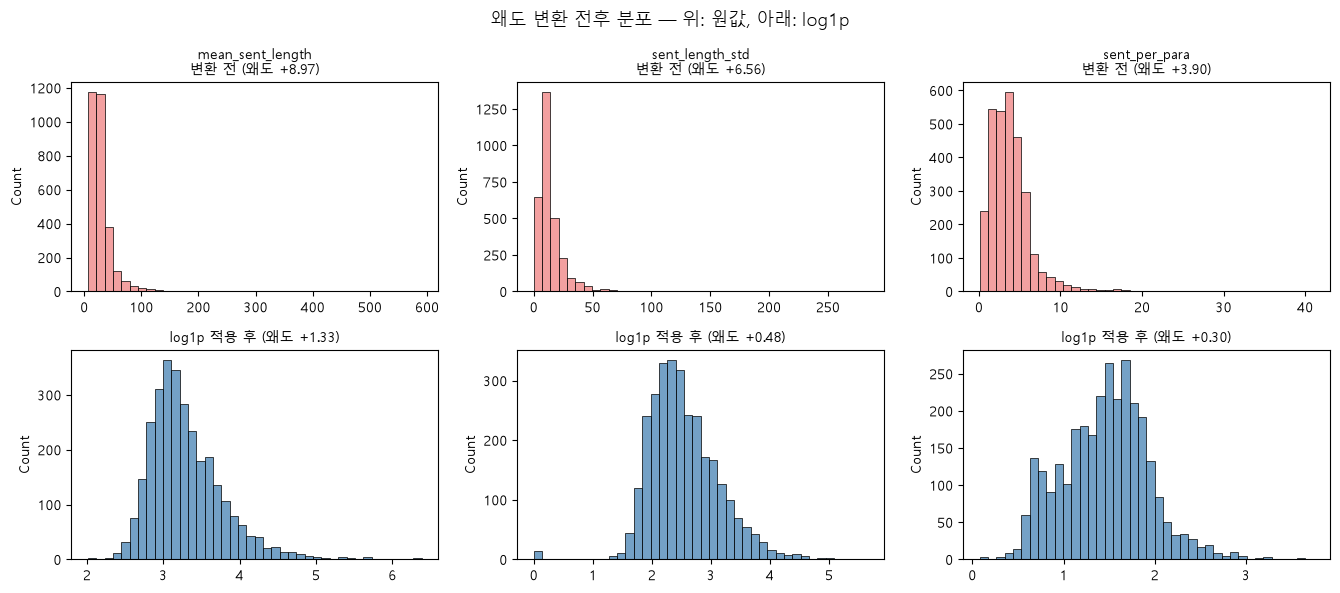

변환 전 CV R² : 0.3003 ± 0.0400
변환 후 CV R² : 0.3092 ± 0.0440   (+0.0090)

변환의 1차 목적은 성능이 아니라 **극단값이 계수를 지배하지 않게 하는 것**입니다.
성능이 함께 오른 것은 그 목적이 달성됐다는 부수적 증거입니다.


In [18]:
# ── [7-4b] 변환 효과 확인 ─────────────────────────────────
#
# 수치만으로는 무엇이 달라졌는지 알기 어려우므로 분포를 직접 봅니다.

if LOG_COLS:
    fig, axes = plt.subplots(2, len(LOG_COLS), figsize=(4.5 * len(LOG_COLS), 6))
    axes = np.atleast_2d(axes)
    for j, c in enumerate(LOG_COLS):
        sns.histplot(train_df[c], bins=40, ax=axes[0, j], color='lightcoral')
        axes[0, j].set_title(f'{c}\n변환 전 (왜도 {train_df[c].skew():+.2f})', fontsize=10)
        axes[0, j].set_xlabel('')
        sns.histplot(np.log1p(train_df[c]), bins=40, ax=axes[1, j], color='steelblue')
        axes[1, j].set_title(f'log1p 적용 후 (왜도 {np.log1p(train_df[c]).skew():+.2f})',
                             fontsize=10)
        axes[1, j].set_xlabel('')
    fig.suptitle('왜도 변환 전후 분포 — 위: 원값, 아래: log1p', fontsize=13)
    plt.tight_layout()
    plt.show()

# 예측력에 미친 영향도 확인합니다.
_X_raw = train_df[SELECTED]
_X_log = _X_raw.copy()
for c in LOG_COLS:
    _X_log[c] = np.log1p(_X_log[c])

_m0, _s0 = cv_r2(_X_raw)
_m1, _s1 = cv_r2(_X_log)
print(f'변환 전 CV R² : {_m0:.4f} ± {_s0:.4f}')
print(f'변환 후 CV R² : {_m1:.4f} ± {_s1:.4f}   ({_m1 - _m0:+.4f})')
print()
print('변환의 1차 목적은 성능이 아니라 **극단값이 계수를 지배하지 않게 하는 것**입니다.')
print('성능이 함께 오른 것은 그 목적이 달성됐다는 부수적 증거입니다.')

In [19]:
# ── [7-5] 스케일러 선택 ───────────────────────────────────
#
# 두 후보:
#   StandardScaler — (x - 평균) / 표준편차. 평균과 표준편차가 극단값에 끌립니다.
#   RobustScaler   — (x - 중앙값) / IQR. 중앙값과 사분위수 기반이라 극단값에 둔감합니다.
#
# 이 데이터에는 극단값이 남아 있으므로 RobustScaler가 유리할 것으로 예상됩니다.
# 예상은 예상일 뿐이므로 측정합니다.

from sklearn.pipeline import make_pipeline

rows = []
for sc_name, sc in [('StandardScaler', StandardScaler()), ('RobustScaler', RobustScaler())]:
    for alpha in [1.0, 10.0]:
        s = cross_val_score(make_pipeline(sc, Ridge(alpha=alpha)),
                            _X_log, y_train, cv=CV, scoring='r2')
        rows.append({'스케일러': sc_name, 'Ridge alpha': alpha,
                     'CV R²': round(s.mean(), 4), '±': round(s.std(), 4)})
sc_bench = pd.DataFrame(rows)
print(sc_bench.to_string(index=False))

print(f'\n최대 차이: {sc_bench["CV R²"].max() - sc_bench["CV R²"].min():.4f} '
      f'(표준편차 ±{sc_bench["±"].mean():.4f})')
print()
print('두 스케일러의 차이가 측정되지 않습니다. [7-4]의 로그 변환이 이미')
print('극단값의 영향을 줄여, RobustScaler의 이점이 상쇄됐기 때문입니다.')
print()
print('StandardScaler를 채택합니다.')
print('  · 성능이 동일하므로 해석이 쉬운 쪽을 고릅니다.')
print('  · 표준화 계수는 "표준편차 1만큼 변할 때 점수가 얼마나 변하는가"로 읽히며,')
print('    변수 간 중요도를 직접 비교할 수 있습니다. IQR 기준은 이 해석이 덜 직관적입니다.')
print('  · Ridge/Lasso의 정규화 항은 계수 크기에 비례하므로,')
print('    변수들이 같은 척도에 놓여야 벌점이 공평하게 걸립니다.')

          스케일러  Ridge alpha  CV R²      ±
StandardScaler          1.0 0.3092 0.0440
StandardScaler         10.0 0.3093 0.0440
  RobustScaler          1.0 0.3094 0.0441
  RobustScaler         10.0 0.3098 0.0445

최대 차이: 0.0006 (표준편차 ±0.0441)

두 스케일러의 차이가 측정되지 않습니다. [7-4]의 로그 변환이 이미
극단값의 영향을 줄여, RobustScaler의 이점이 상쇄됐기 때문입니다.

StandardScaler를 채택합니다.
  · 성능이 동일하므로 해석이 쉬운 쪽을 고릅니다.
  · 표준화 계수는 "표준편차 1만큼 변할 때 점수가 얼마나 변하는가"로 읽히며,
    변수 간 중요도를 직접 비교할 수 있습니다. IQR 기준은 이 해석이 덜 직관적입니다.
  · Ridge/Lasso의 정규화 항은 계수 크기에 비례하므로,
    변수들이 같은 척도에 놓여야 벌점이 공평하게 걸립니다.


In [20]:
# ── [7-6] 최종 변환 실행 및 누수 검증 ─────────────────────
#
# 순서: 로그 변환 → 표준화 → 더미 결합
#
# 더미를 표준화하지 않는 이유:
#   0/1 값을 표준화하면 "그 범주가 아님"이 0이 아닌 음수가 되어
#   희소 구조가 깨지고 해석도 어려워집니다.
#   트리 계열에서는 분기 기준이 왜곡됩니다.


def apply_log(df):
    out = df[SELECTED].copy()
    for c in LOG_COLS:
        out[c] = np.log1p(out[c])
    return out


X_train_num = apply_log(train_df)
X_test_num = apply_log(test_df)      # test에도 같은 함수를 적용 (학습되는 값 없음)

scaler = StandardScaler()
scaler.fit(X_train_num)              # ← fit은 train에만

X_train_scaled_num = pd.DataFrame(scaler.transform(X_train_num),
                                  columns=SELECTED, index=train_df.index)
X_test_scaled_num = pd.DataFrame(scaler.transform(X_test_num),
                                 columns=SELECTED, index=test_df.index)

print('=' * 72)
print('누수 검증 — train으로만 fit했다면 test 평균은 0에서 벗어나야 합니다')
print('=' * 72)
chk = pd.DataFrame({
    'train 평균': X_train_scaled_num.mean().round(6),
    'train 표준편차': X_train_scaled_num.std(ddof=0).round(6),
    'test 평균': X_test_scaled_num.mean().round(4),
    'test 표준편차': X_test_scaled_num.std(ddof=0).round(4),
})
print(chk.to_string())

_tr_ok = X_train_scaled_num.mean().abs().max() < 1e-10
_te_off = X_test_scaled_num.mean().abs().max()
print(f'\ntrain 평균 최대 절댓값: {X_train_scaled_num.mean().abs().max():.2e}  '
      f'→ {"정확히 0 (정상)" if _tr_ok else "이상"}')
print(f'test  평균 최대 절댓값: {_te_off:.4f}  '
      f'→ {"0이 아님 (정상 — 누수 없음)" if _te_off > 1e-6 else "0임 (누수 의심)"}')
print()
print('test 평균이 0에서 벗어난 정도는 두 집합의 자연스러운 분포 차이입니다.')
print('층화 추출로 타겟 분포는 맞췄지만, 피처 분포까지 일치시킨 것은 아니기 때문입니다.')

누수 검증 — train으로만 fit했다면 test 평균은 0에서 벗어나야 합니다
                       train 평균  train 표준편차  test 평균  test 표준편차
flag_very_short             0.0         1.0  -0.0260     0.8169
MTLD_valid                  0.0         1.0   0.0560     1.0139
guiraud                    -0.0         1.0   0.0373     0.9938
herdan_c                    0.0         1.0   0.0219     0.9584
k2_ratio                   -0.0         1.0  -0.0129     1.0326
mean_word_length           -0.0         1.0  -0.0373     0.9951
mean_syllables              0.0         1.0  -0.0214     0.9660
academic_suffix_ratio       0.0         1.0   0.0010     0.9598
oov_ratio                  -0.0         1.0  -0.0397     0.9013
hapax_ratio                 0.0         1.0   0.0247     0.9638
mean_sent_length           -0.0         1.0   0.0032     1.0392
sent_per_para               0.0         1.0   0.0195     0.9966
sent_length_std            -0.0         1.0  -0.0584     1.0330
len_z_in_prompt            -0.0         1.0   0.0657     1

In [21]:
# ── [7-7] 최종 행렬 구성 및 저장 ──────────────────────────
#
# 네 종류를 저장합니다. 모델 계열마다 필요한 형태가 다르기 때문입니다.
#
#   X_*.csv         원값 + 더미        → Random Forest 등 트리 계열
#   X_*_scaled.csv  로그+표준화 + 더미 → Linear / Ridge / Lasso
#
# 더미를 뺀 조건은 파일을 따로 만들지 않고 컬럼 슬라이싱으로 처리합니다.
#   X_train[NUM_FEATURES]   ← 이 한 줄이면 됩니다.

X_train = pd.concat([train_df[SELECTED].reset_index(drop=True),
                     enc_train.reset_index(drop=True)], axis=1)
X_test = pd.concat([test_df[SELECTED].reset_index(drop=True),
                    enc_test.reset_index(drop=True)], axis=1)

X_train_scaled = pd.concat([X_train_scaled_num.reset_index(drop=True),
                            enc_train.reset_index(drop=True)], axis=1)
X_test_scaled = pd.concat([X_test_scaled_num.reset_index(drop=True),
                           enc_test.reset_index(drop=True)], axis=1)

for name, obj in [('X_train', X_train), ('X_test', X_test),
                  ('X_train_scaled', X_train_scaled), ('X_test_scaled', X_test_scaled)]:
    obj.to_csv(f'data/{name}.csv', index=False)

y_train.reset_index(drop=True).to_csv('data/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv('data/y_test.csv', index=False)

# 변환기를 저장합니다. 대시보드의 예측 시스템은 사용자 입력에 대해
# 학습 때와 **완전히 동일한 변환**을 적용해야 합니다.
# 코드를 다시 짜면 미세한 차이가 생기므로 학습 시점의 객체를 그대로 씁니다.
artifacts = {
    'selected_features': SELECTED,
    'log_cols': LOG_COLS,
    'dummy_cols': DUMMY_COLS,
    'scaler': scaler,
    'encoder': encoder,
    'known_prompts': sorted(KNOWN_PROMPTS),
    'min_prompt_n': MIN_PROMPT_N,
    'token_prompt_stats': _stat,        # len_z_in_prompt 재계산용 (train 기준)
    'token_global': (TOKEN_GM, TOKEN_GS),
    'seed': SEED,
    'target': TARGET,
}
joblib.dump(artifacts, 'data/preprocessor.joblib')

with open('data/selected_features.json', 'w', encoding='utf-8') as f:
    json.dump({'numeric': SELECTED, 'log_transformed': LOG_COLS,
               'dummies': DUMMY_COLS}, f, ensure_ascii=False, indent=2)

print('저장 완료')
print(f'  data/X_train.csv          {X_train.shape}   (원값 + 더미 · 트리 계열용)')
print(f'  data/X_test.csv           {X_test.shape}')
print(f'  data/X_train_scaled.csv   {X_train_scaled.shape}   (로그+표준화 · 선형 계열용)')
print(f'  data/X_test_scaled.csv    {X_test_scaled.shape}')
print(f'  data/y_train.csv          ({len(y_train)},)')
print(f'  data/y_test.csv           ({len(y_test)},)')
print(f'  data/preprocessor.joblib  (scaler · encoder · 그룹통계 — 대시보드용)')
print(f'  data/selected_features.json')
print(f'  data/feature_selection_log.csv')
print()
print(f'수치 변수 {len(SELECTED)}개 + 더미 {len(DUMMY_COLS)}개 = 총 {X_train.shape[1]}개 열')
print(f'결측치: train {X_train.isna().sum().sum()}개 / test {X_test.isna().sum().sum()}개')
print(f'무한값: train {np.isinf(X_train.values).sum()}개 / test {np.isinf(X_test.values).sum()}개')

저장 완료
  data/X_train.csv          (2997, 51)   (원값 + 더미 · 트리 계열용)
  data/X_test.csv           (750, 51)
  data/X_train_scaled.csv   (2997, 51)   (로그+표준화 · 선형 계열용)
  data/X_test_scaled.csv    (750, 51)
  data/y_train.csv          (2997,)
  data/y_test.csv           (750,)
  data/preprocessor.joblib  (scaler · encoder · 그룹통계 — 대시보드용)
  data/selected_features.json
  data/feature_selection_log.csv

수치 변수 15개 + 더미 36개 = 총 51개 열
결측치: train 0개 / test 0개
무한값: train 0개 / test 0개


In [22]:
# ── [7-8] STEP 4 진입 전 최종 확인 ────────────────────────
#
# 다음 노트북이 바로 쓸 수 있는 상태인지 점검합니다.
# 여기서 잡히지 않는 문제는 모델링 도중에 터집니다.

checks = [
    ('train/test 열 구성 일치', list(X_train.columns) == list(X_test.columns)),
    ('scaled 열 구성 일치', list(X_train_scaled.columns) == list(X_test_scaled.columns)),
    ('행 수 보존 (train)', len(X_train) == len(train_df) == len(y_train)),
    ('행 수 보존 (test)', len(X_test) == len(test_df) == len(y_test)),
    ('결측 없음', X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0),
    ('무한값 없음', not np.isinf(X_train.values).any() and not np.isinf(X_test.values).any()),
    ('전부 수치형', all(X_train.dtypes.apply(lambda d: d.kind in 'if'))),
    ('타겟 미포함', TARGET not in X_train.columns),
    ('원문 미포함', 'full_text' not in X_train.columns),
    ('완전 종속 없음 (VIF < ∞)', not np.isinf(vif_series(X_train, SELECTED)).any()),
    ('최대 VIF < 10', vif_series(X_train, SELECTED).max() < TH_VIF),
    ('train 표준화 평균 ≈ 0', X_train_scaled[SELECTED].mean().abs().max() < 1e-10),
    ('test 표준화 평균 ≠ 0 (누수 없음)', X_test_scaled[SELECTED].mean().abs().max() > 1e-6),
]

print('=' * 72)
for name, ok in checks:
    print(f'  {"✓" if ok else "✗"}  {name}')
print('=' * 72)
print(f'{sum(1 for _, ok in checks if ok)} / {len(checks)} 통과')

# 베이스라인을 다시 확인합니다. STEP 4의 모든 모델은 이 값을 넘어야 합니다.
_mae0 = (y_train - y_train.mean()).abs().mean()
_rmse0 = np.sqrt(((y_train - y_train.mean()) ** 2).mean())
_m, _s = cv_r2(X_train_scaled[SELECTED])
print(f'\n참고 지표')
print(f'  평균 예측 베이스라인 : MAE {_mae0:.4f} / RMSE {_rmse0:.4f} / R² 0.0000')
print(f'  현재 피처 + Ridge    : CV R² {_m:.4f} ± {_s:.4f}')
print(f'  → STEP 4의 모델은 최소한 이 수준은 재현해야 합니다.')

  ✓  train/test 열 구성 일치
  ✓  scaled 열 구성 일치
  ✓  행 수 보존 (train)
  ✓  행 수 보존 (test)
  ✓  결측 없음
  ✓  무한값 없음
  ✓  전부 수치형
  ✓  타겟 미포함
  ✓  원문 미포함
  ✓  완전 종속 없음 (VIF < ∞)
  ✓  최대 VIF < 10
  ✓  train 표준화 평균 ≈ 0
  ✓  test 표준화 평균 ≠ 0 (누수 없음)
13 / 13 통과

참고 지표
  평균 예측 베이스라인 : MAE 0.4700 / RMSE 0.5795 / R² 0.0000
  현재 피처 + Ridge    : CV R² 0.3092 ± 0.0440
  → STEP 4의 모델은 최소한 이 수준은 재현해야 합니다.


---

# 정리

## STEP 6 결과

| 항목 | 값 |
|---|---|
| 입력 | 41열 (파생 28 + 원본 9 + 범주형 2 + 타겟 + 원문) |
| 신규 생성 | `clean_beyond_2k` 1개 (`clean_soph_z`는 검토 후 기각) |
| 누수 재계산 | `len_z_in_prompt`, `prompt_grouped` |
| 최종 선택 | 수치 변수 15개 |
| 선택 손실 | 교차검증 표준편차 이내 |
| 최대 VIF | 10 미만 — 계수 해석 가능 |

## STEP 7 결과

| 항목 | 처리 |
|---|---|
| 범주형 | `prompt_grouped` 원핫 (train fit, `handle_unknown='ignore'`, `drop='first'`) |
| 왜도 변환 | 사전 선언 기준을 통과한 변수만 `log1p` |
| 스케일링 | `StandardScaler` (train fit) — 선형 계열용 행렬에만 적용 |
| 산출물 | 트리용·선형용 행렬 각 1쌍 + 변환기 객체 |

## `프로젝트_진행_단계.md` 갱신

```
#### 2. 데이터 전처리
[v] 결측치 확인 및 처리
[v] 이상치 확인 및 처리
[v] 중복 데이터 제거
[v] 데이터 타입 변환
[v] 범주형 데이터 처리      ← STEP 7-1, 7-2
[v] Feature Selection       ← STEP 6
[v] Encoding, Scaling       ← STEP 7
[v] 학습/테스트 데이터 분리  ← STEP 5 (03 노트북)

#### 3. 데이터 분석 및 EDA
[v] 전 항목 — 03 노트북에서 완료
```

전처리(20점)와 EDA(10점) 항목이 모두 채워졌습니다.

---

## 이 두 단계에서 판단이 갈렸던 지점

발표나 보고서에서 설명할 가치가 있는 것은 결과보다 **선택의 근거**입니다.

| 지점 | 선택 | 근거 |
|---|---|---|
| 분할 전 계산된 그룹 통계 | 제거가 아니라 **재계산** | 변수 자체는 유효하고 절차만 문제였음 |
| 길이 변수 처리 | 제외가 아니라 **명시적 포함** | 교란변수는 넣어야 나머지 계수를 통제된 상태로 읽을 수 있음 |
| `len_z_in_prompt` vs `Token` | 규칙 결과 유지 + **재해석** | 교체안이 VIF 기준을 위반. 이름 대신 실측으로 의미를 기술 |
| prompt 원핫 | 만들되 **기본은 미사용** | 단독 R² ≈ 0. 격차는 소표본의 우연 |
| 왜도 변환 | **효과가 확인된 변수만** | 비율 변수는 로그를 씌워도 모양이 바뀌지 않음 |
| 스케일러 | 성능 동률 → **해석 쉬운 쪽** | 표준화 계수는 변수 간 중요도 비교가 가능 |

## 다음 단계 — STEP 4. 회귀 모델 구축 (진행 단계 문서 기준 4단계)

| 항목 | 내용 |
|---|---|
| 사용 파일 | `X_train_scaled.csv` (선형), `X_train.csv` (트리) |
| 모델 | Linear Regression · Ridge · Lasso · Random Forest Regressor |
| 평가 | MAE · MSE · RMSE · R² |
| 필수 비교 | ① 더미 포함 vs 미포함 ② 선형 vs 트리 |

### 넘어가기 전에 기억해 둘 것

1. **test는 아직 열지 않습니다.** 모델 선택과 하이퍼파라미터 조정은 전부 train 교차검증으로 합니다.
   test는 최종 모델 하나를 확정한 뒤 딱 한 번 사용합니다.
2. **기대 성능은 R² 0.30 근처입니다.** 02 노트북의 목표 구간(0.30~0.45) 하단에 해당하며,
   `Vocabulary`의 채점자 간 일치도(Cohen's κ = .518)가 7개 항목 중 최하위라는 점을 함께 보고하면
   상한이 왜 낮은지 설명할 수 있습니다.
3. **잔차 분석에서 나타날 패턴은 이미 예고돼 있습니다.**
   03 EDA 2에서 확인한 대로 저점수 구간은 과대예측, 고점수 구간은 과소예측될 것입니다.
   관측 30건 미만 구간(1.0 / 1.5 / 5.0점, 합계 40건)이 원인입니다.

### STEP 5(성능 향상)를 위해 남겨 둔 재료

이 노트북에서 측정은 했지만 채택하지 않은 것들입니다. 근거가 이미 기록돼 있으므로
성능 향상 단계에서 바로 실험할 수 있습니다.

- 형태 계열 3인방(`mean_word_length`, `mean_syllables`, `long_word_ratio` 계통)은
  VIF 5 내외로 같은 구성 개념을 재고 있습니다. 하나로 줄였을 때의 비용은 [6-10] 방식으로 측정 가능합니다.
- `herdan_c` · `Token` 등 [6-9]에서 기각한 조합은 VIF 기준을 완화하면 후보로 돌아옵니다.
  단, 계수 해석을 포기하는 대가가 따릅니다.
- 희소 구간(1.0 / 1.5 / 5.0점)에 대한 표본 가중치 부여.